
### Basic Data Plotting

One of the most fundamental tasks in data analysis/modeling is to read data from files and plot them. In this section, we will learn how to read data from files and plot them using `matplotlib`.

Let's begin by importing the necessary libraries.


In [1]:
import csv
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

We will use the `csv` library to read data from files, `matplotlib` to plot data, `scipy` to fit data to a function, and `numpy` to perform numerical operations.

Let's write a function to read data from a CSV file. The function takes the filename as input and returns five lists: the (string) header label for each column in the data file, the x data, the y data, the error in x values, and the error in y values. The function assumes that the first row of the CSV file contains the column headers.

In [2]:
def read_data(filename):
    x = []
    y = []
    dx = []
    dy = []

    with open(filename, 'r') as file:
        reader = csv.reader(file)
        headers = next(reader, None)
        for row in reader:
            x.append(float(row[0]))
            y.append(float(row[1]))
            dx.append(float(row[2]))
            dy.append(float(row[3]))

    return headers, x, y, dx, dy

Next, we write the main program. We read the data using the function above and then plot the measurements with their $x$ and $y$ error bars, appropriate axis labels, and a title. We also set the lower limit of the $y$-axis to zero. Logarithmic $x$ or $y$ scales can be enabled when they are appropriate for the data.

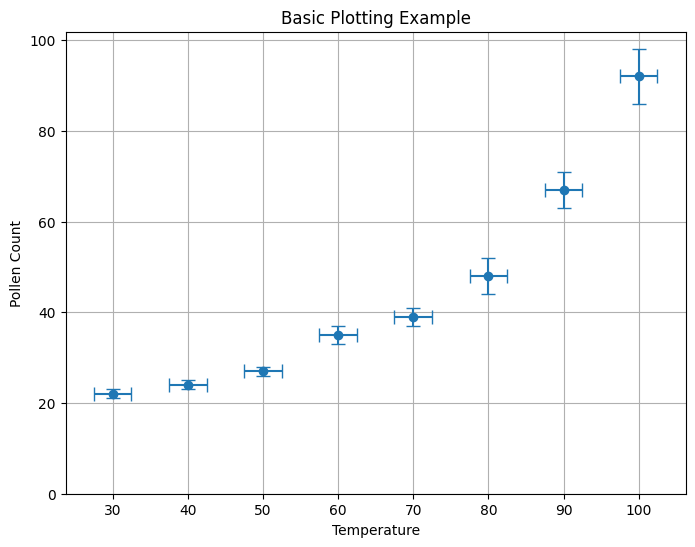

In [3]:
# Step 1:  Read the data into appropriate data structures
file_name = "testdata.csv"
header_values, xi, yi, dxi, dyi = read_data(file_name)

# print(header_values)
# print(xi, yi, dxi, dyi)

# Step 2: Basic plot of the data with error bars, plot title, and axis labels
fig, ax = plt.subplots(1,1, figsize=(8, 6))
ax.errorbar(xi, yi, xerr=dxi, yerr=dyi, fmt='o', label="Pollen Count Data", capsize=5.0)
ax.set_title("Basic Plotting Example")
ax.set_xlabel(header_values[0])
ax.set_ylabel(header_values[1])

# Make sure lower limit of y-axis is zero!
ax.set_ylim(0)
ax.grid()

# Possibly, choose logarithmic x and/or y scales.
# plt.xscale('log')
# plt.yscale('log')

Now, we can fit the data!  We define an appropriate fitting function (two, in this case - one for a quadratic fit and one for an exponential fit), and then use the `curve_fit` function from `scipy` to fit the data.  We also print out the fit parameters and their uncertainties, and the covariance matrix.

In [4]:
# Step 3a: Define a quadratic fit function
def fitfunction(x, *param):
    return param[0]*x*x + param[1]*x + param[2]

# Step 3a: Define an exponential+bkgd fit function
def expfunction(x, *param):
    return param[0]*np.exp(param[1]*x) + param[2]

fitchoice = 2

if fitchoice == 1:
    # Step 3b:  Fit the data with quadratic
    init_vals = [0 for x in range(3)]
    popt, pcov = curve_fit(fitfunction, xi, yi, p0=init_vals, sigma=dyi, absolute_sigma=True)
else:
    # Step 3b:  Fit the data with exponential + background
    init_vals = [1.0, 0.01, 10.00]  # N.B. need to choose initial guesses that make sense!!!
    popt, pcov = curve_fit(expfunction, xi, yi, p0=init_vals, sigma=dyi, absolute_sigma=True)

perr = np.sqrt(np.diag(pcov))

print(popt)
print(perr)
print(pcov)

[ 1.33225932  0.04012304 17.48103181]
[0.62438827 0.00485997 2.05429664]
[[ 3.89860709e-01 -3.01327650e-03 -1.22232890e+00]
 [-3.01327650e-03  2.36192636e-05  9.25375142e-03]
 [-1.22232890e+00  9.25375142e-03  4.22013468e+00]]


Extract the fitted parameters and their uncertainties and display them in a more readable form. The parameter uncertainties are the square roots of the diagonal elements of the covariance matrix.

In [5]:
a = popt[0]
b = popt[1]
c = popt[2]
da = perr[0]
db = perr[1]
dc = perr[2]
if fitchoice == 1:
    print(f'Fit Result: y = ({a:.5f} +/- {da:.5f})x^2 + ({b:.5f} +/- {db:.5f})x + ({c:.5f} +/- {dc:.5f})')
else:
    print(f'Fit Result: y = ({a:.5f} +/- {da:.5f})e(({b:.5f} +/- {db:.5f})x) + ({c:.5f} +/- {dc:.5f})')

Fit Result: y = (1.33226 +/- 0.62439)e((0.04012 +/- 0.00486)x) + (17.48103 +/- 2.05430)


Plot the fit result on top of the data.

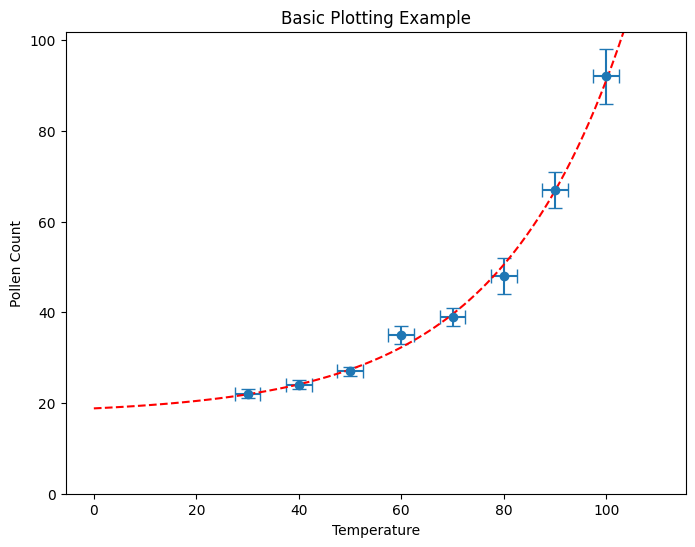

In [6]:
# Step 3d:  Plot the fit result
xlow = min(xi) - 30
xhigh = max(xi) + 10
xfit = np.linspace(xlow, xhigh, 100)

if fitchoice == 1:
    yfit = fitfunction(xfit, *popt)
    ax.plot(xfit, yfit, 'r--', label=f"Quadratic Fit: \ny = ({a:.4f} +/- {da:.4f})x^2 + \n({b:.2f} +/- {db:.2f})x + \n({c:.2f} +/- {dc:.2f})")

else:
    yfit = expfunction(xfit, *popt)
    ax.plot(xfit, yfit, 'r--', label=f"Exponential Fit: \ny = ({a:.4f} +/- {da:.4f})e^(({b:.3f} +/- {db:.3f})x) + \n({c:.2f} +/- {dc:.2f})")

ax.grid()

fig


## Plot a one-sigma uncertainty band

The covariance matrix describes both the uncertainty of each fitted parameter and the correlations among parameters. To propagate that information to the fitted curve, we draw many parameter vectors from the multivariate normal approximation defined by `popt` and `pcov`. Each parameter vector produces a possible quadratic or exponential curve.

At every value of $x$, the 16th and 84th percentiles of these curves enclose the central 68% interval—approximately a one-standard-deviation band when the distribution is Gaussian. `fill_between` shades the region between those limits so the uncertainty is visible without adding two more curves that could be mistaken for additional fits.

This is a **fit-parameter uncertainty band**: it shows uncertainty in the estimated mean curve arising from uncertainty in the fitted coefficients. It is not a prediction interval for a new measurement. A prediction interval would also include the expected scatter of individual measurements about the model and would therefore generally be wider. For a nonlinear model such as the exponential, the multivariate normal parameter distribution is an approximation whose quality depends on how nearly quadratic the $\chi^2$ surface is near its minimum.

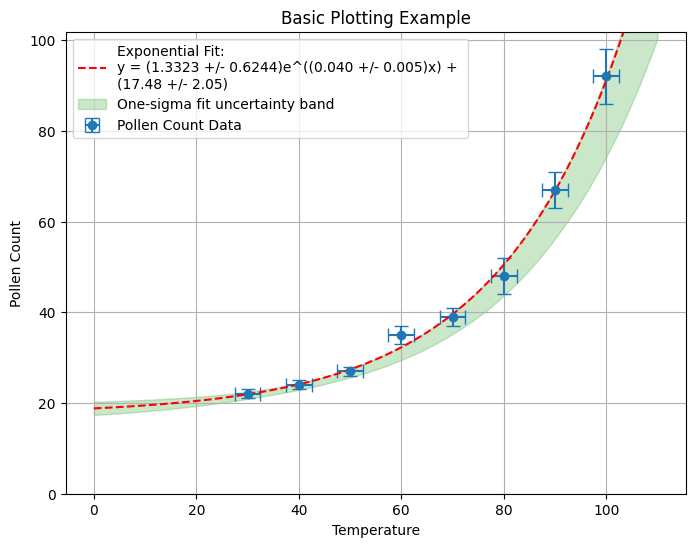

In [7]:
# Step 4:  Plot the error band
plot_error_band = True

if plot_error_band:
    # Use a fixed seed so the displayed band is reproducible.
    rng = np.random.default_rng(441)
    parameter_samples = rng.multivariate_normal(popt, pcov, size=10000)
    if fitchoice == 1:
        sampled_fits = np.asarray([fitfunction(xfit, *parameters)
                                    for parameters in parameter_samples])
    else:
        sampled_fits = np.asarray([expfunction(xfit, *parameters)
                                    for parameters in parameter_samples])

    lower = np.percentile(sampled_fits, 16.0, axis=0)
    upper = np.percentile(sampled_fits, 84.0, axis=0)
    ax.fill_between(xfit, lower, upper, color='tab:green', alpha=0.25,
                    label=r'One-sigma fit uncertainty band')

    ax.legend()
    ax.grid()

fig

In [8]:
# Calculate Goodness of Fit:
if fitchoice == 1:
    yfit2 = fitfunction(np.array(xi), *popt)
else:
    yfit2 = expfunction(np.array(xi), *popt)

chi2 = 0.0
for i in range(len(xi)):
    # print(yi[i],yfit2[i],dyi[i])
    chi2 += (yi[i]-yfit2[i])**2/dyi[i]**2

print(f"Goodness of Fit (reduced chi^2) = {chi2/(len(xi)-1-len(init_vals))}")

Goodness of Fit (reduced chi^2) = 0.6296594341126813


## A nonlinear alternative: parametric bootstrap

The covariance-sampling method above assumes that the fitted parameters follow a multivariate normal distribution. Equivalently, it approximates the $\chi^2$ surface near its minimum by a quadratic bowl. That local approximation is often effective for linear models, but it may describe a nonlinear exponential model poorly when the parameter distribution is curved, asymmetric, or strongly correlated.

A **parametric bootstrap** repeats the complete fitting procedure instead:

1. Use the best-fit curve as a provisional model for the mean value at each measured $x_i$.
2. Generate a synthetic data set by adding an independent Gaussian random offset with standard deviation $\sigma_i$ to each model value.
3. Refit the synthetic data using the same model, uncertainties, and fitting procedure as the original data.
4. Repeat many times and evaluate every successful fitted curve on the plotting grid.
5. At each $x$, use the 16th and 84th percentiles of the refitted curves as the central 68% bootstrap band.

Because every synthetic data set is refitted, this procedure passes the measurement fluctuations through the full nonlinear optimization instead of imposing a multivariate-normal shape directly on parameter space. The new figure is deliberately separate from the covariance-normal figure so each uncertainty construction can be examined on its own.

This method still makes assumptions: the selected fitting function is treated as correct, the quoted $y$ uncertainties are treated as known independent Gaussian standard deviations, and the $x$ uncertainties are not included in the fit. The result remains an uncertainty band for the fitted mean curve, not a prediction interval for a new individual observation.

Successful bootstrap fits: 2000 / 2000


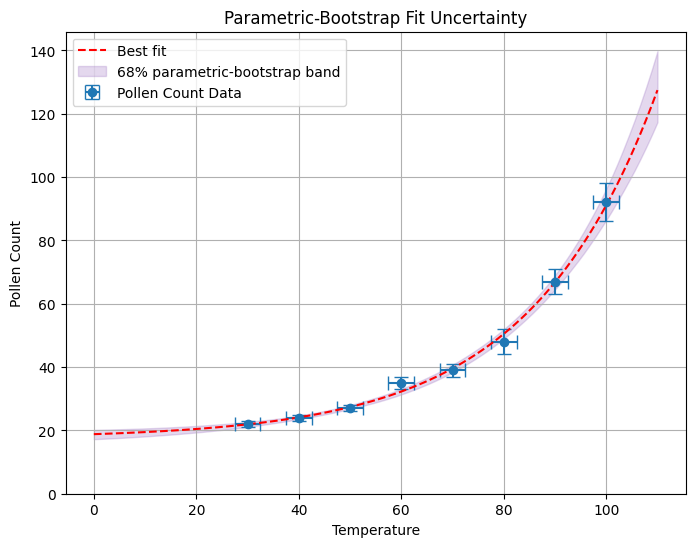

In [9]:
# Step 5: Estimate the fit-curve uncertainty with a parametric bootstrap.
number_of_bootstrap_samples = 2000
bootstrap_rng = np.random.default_rng(442)

x_data = np.asarray(xi)
y_uncertainty = np.asarray(dyi)
model_function = fitfunction if fitchoice == 1 else expfunction
best_fit_at_data = model_function(x_data, *popt)
bootstrap_curves = []

for _ in range(number_of_bootstrap_samples):
    synthetic_y = bootstrap_rng.normal(best_fit_at_data, y_uncertainty)
    try:
        bootstrap_parameters, _ = curve_fit(
            model_function, x_data, synthetic_y, p0=popt,
            sigma=y_uncertainty, absolute_sigma=True, maxfev=10000
        )
        bootstrap_curve = model_function(xfit, *bootstrap_parameters)
        if np.all(np.isfinite(bootstrap_curve)):
            bootstrap_curves.append(bootstrap_curve)
    except (RuntimeError, ValueError, FloatingPointError):
        # A failed nonlinear fit contributes no curve to the bootstrap band.
        pass

bootstrap_curves = np.asarray(bootstrap_curves)
if len(bootstrap_curves) == 0:
    raise RuntimeError("All bootstrap fits failed")

bootstrap_lower = np.percentile(bootstrap_curves, 16.0, axis=0)
bootstrap_upper = np.percentile(bootstrap_curves, 84.0, axis=0)

fig_bootstrap, ax_bootstrap = plt.subplots(figsize=(8, 6))
ax_bootstrap.errorbar(xi, yi, xerr=dxi, yerr=dyi, fmt='o', capsize=5.0,
                      label="Pollen Count Data")
ax_bootstrap.plot(xfit, yfit, 'r--', label='Best fit')
ax_bootstrap.fill_between(
    xfit, bootstrap_lower, bootstrap_upper,
    color='tab:purple', alpha=0.25, label='68% parametric-bootstrap band'
)
ax_bootstrap.set_title("Parametric-Bootstrap Fit Uncertainty")
ax_bootstrap.set_xlabel(header_values[0])
ax_bootstrap.set_ylabel(header_values[1])
ax_bootstrap.set_ylim(0)
ax_bootstrap.grid()
ax_bootstrap.legend()

print(f"Successful bootstrap fits: {len(bootstrap_curves)} / "
      f"{number_of_bootstrap_samples}")

## The exponential model's three-dimensional likelihood surface

The exponential-plus-background model also has three parameters,

$$f(x;A,k,C)=A e^{kx}+C,$$

so we can repeat the three-dimensional parameter-space experiment using amplitude $A$, exponential coefficient $k$, and constant background $C$ as the axes. At every grid point we directly evaluate

$$\chi^2(A,k,C)=\sum_i\left[\frac{y_i-f(x_i;A,k,C)}{\sigma_i}\right]^2$$

and convert it to relative likelihood,

$$\frac{L(A,k,C)}{L_{\max}}=\exp\left[-\frac{\chi^2(A,k,C)-\chi^2_{\min}}{2}\right].$$

The covariance matrix is used only to choose the displayed $\pm1\sigma$ range on each axis. It is **not** used to calculate the density values. Those values come from the full exponential function and the original definition of $\chi^2$. This distinction lets the visualization test the quadratic-bowl approximation rather than assuming it.

If the likelihood were accurately multivariate normal over this region, its equal-density surfaces would be nested ellipsoids. Curvature, skewness, changing width, or a banana-shaped ridge would reveal nonlinear parameter dependence. The parameters are expected to be strongly coupled: for example, a change in amplitude can be partly compensated by changes in exponential coefficient and background. If the surface still appears nearly ellipsoidal within $\pm1\sigma$, expanding the viewing range would generally make departures from the local approximation easier to see.

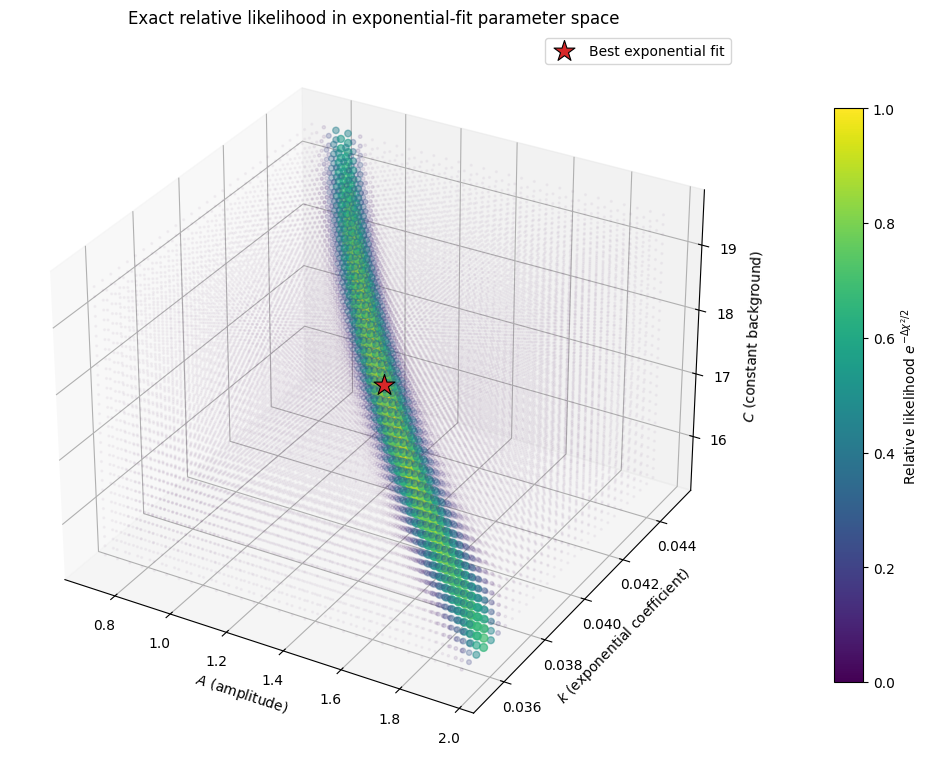

In [10]:
# Step 6: Map the exact exponential-model likelihood in (A, k, C) space.
x_data_likelihood = np.asarray(xi)
y_data_likelihood = np.asarray(yi)
y_uncertainty_likelihood = np.asarray(dyi)

# Perform an explicit exponential fit so this section remains valid even
# if fitchoice was changed to the quadratic model above.
exponential_best_parameters, exponential_covariance = curve_fit(
    expfunction, x_data_likelihood, y_data_likelihood,
    p0=[1.0, 0.01, 10.0], sigma=y_uncertainty_likelihood,
    absolute_sigma=True, maxfev=10000
)
exponential_parameter_errors = np.sqrt(np.diag(exponential_covariance))
amplitude, exponential_coefficient, background = exponential_best_parameters
d_amplitude, d_exponential_coefficient, d_background = exponential_parameter_errors

number_of_likelihood_grid_points = 29
amplitude_values = np.linspace(
    amplitude-d_amplitude, amplitude+d_amplitude,
    number_of_likelihood_grid_points
)
coefficient_values = np.linspace(
    exponential_coefficient-d_exponential_coefficient,
    exponential_coefficient+d_exponential_coefficient,
    number_of_likelihood_grid_points
)
background_values = np.linspace(
    background-d_background, background+d_background,
    number_of_likelihood_grid_points
)
amplitude_grid, coefficient_grid, background_grid = np.meshgrid(
    amplitude_values, coefficient_values, background_values, indexing='ij'
)

exponential_grid_predictions = (
    amplitude_grid[..., None]
    * np.exp(coefficient_grid[..., None]*x_data_likelihood)
    + background_grid[..., None]
)
exponential_chi2_grid = np.sum(
    ((y_data_likelihood-exponential_grid_predictions)
     / y_uncertainty_likelihood)**2, axis=-1
)
exponential_chi2_min = np.sum(
    ((y_data_likelihood
      - expfunction(x_data_likelihood, *exponential_best_parameters))
     / y_uncertainty_likelihood)**2
)
exponential_delta_chi2 = np.maximum(
    exponential_chi2_grid-exponential_chi2_min, 0.0
)
exponential_relative_likelihood = np.exp(-0.5*exponential_delta_chi2)

flat_exponential_likelihood = exponential_relative_likelihood.ravel()
exponential_point_colors = plt.colormaps['viridis'](
    flat_exponential_likelihood
)
exponential_point_colors[:, 3] = 0.03+0.97*flat_exponential_likelihood
exponential_point_sizes = 2.0+45.0*flat_exponential_likelihood

fig_exponential_space = plt.figure(figsize=(10, 8))
ax_exponential_space = fig_exponential_space.add_subplot(
    111, projection='3d', computed_zorder=False
)
ax_exponential_space.scatter(
    amplitude_grid.ravel(), coefficient_grid.ravel(), background_grid.ravel(),
    c=exponential_point_colors, s=exponential_point_sizes,
    depthshade=False, zorder=1
)
ax_exponential_space.scatter(
    amplitude, exponential_coefficient, background, marker='*', s=250,
    color='tab:red', edgecolor='black', linewidth=0.8,
    label='Best exponential fit', zorder=10
)

exponential_color_scale = plt.cm.ScalarMappable(
    norm=plt.Normalize(0.0, 1.0), cmap='viridis'
)
exponential_color_scale.set_array([])
exponential_colorbar = fig_exponential_space.colorbar(
    exponential_color_scale, ax=ax_exponential_space,
    pad=0.10, shrink=0.75
)
exponential_colorbar.set_label(
    r'Relative likelihood $e^{-\Delta\chi^2/2}$'
)

ax_exponential_space.set_xlabel(r'$A$ (amplitude)')
ax_exponential_space.set_ylabel(r'$k$ (exponential coefficient)')
ax_exponential_space.set_zlabel(r'$C$ (constant background)')
ax_exponential_space.set_title(
    'Exact relative likelihood in exponential-fit parameter space'
)
ax_exponential_space.legend()
fig_exponential_space.tight_layout()